La empresa necesita realizar un modelo de fraude. Tu papel como DS es dar una solución de modelo y
mitigar los riesgos de fraude basada en datos. Los datos para realizar el modelo son datos_fraud.csv.

Una vez que obtengas los datos, utiliza todos tus conocimientos y todos los pasos que creas
necesarios para poder entregar un modelo funcional para predecir si un cliente debería de ser
aprobado o no. Entre los pasos que esperamos ver están:
- EDA
- Pre-procesamiento de los datos
- Entrenamiento del modelo
- Testing de modelo
- Una explicación de cómo pondrías este modelo en producción y que tendrías que estarle
cuidando con el tiempo

In [1]:
#!pip install sweetviz
#!pip install ipywidgets

In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("Archivos_aux/datos_fraud.csv")

In [4]:
import sweetviz as sv
#report = sv.analyze(df)
#report.show_html("Salidas/EDA-datos_fraud.html")

Se hace el analisis estadistico preeliminar de las variables.
- Las variables no cuentan con un nombre mas que el ID, la ficha de tiempo, el monto de la transaccion, y la clasificacion de si es fraude o no. 

- Se cuenta con 32 variables sin descripcion con varianzas menores a 2 en la mayor parte de los casos y distribuciones leptocurtucas con datos atipicos en las colas. (Se realizara revision)

- La variable 31 presenta una varianza mayor a las demas por lo que habra que normalizar para evitar dominancia en el modelo.

- No se cuenta con datos nulos o faltantes en ninguna columna. 

- Existen IDs  repetidos siendo el mayor con una repeticion de 18 veces

- Solo hay 492 casos de fraude de una base de 284,807 siendo menos del 1% de los casos.

In [5]:
#!pip install xgboost
#!pip install lightgbm

In [6]:
import lightgbm as lgb
import numpy as np
import pandas as pd

# Modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    roc_auc_score,
)

# Preprocesamiento y Separación
from sklearn.model_selection import StratifiedKFold, train_test_split
from xgboost import XGBClassifier

In [7]:


df['amount'] = df['amount'].astype(np.float64)
# 1. Transformación Logarítmica: np.log1p equivale a log(x + 1)
df['amount_log'] = np.log1p(df['amount'])

df['es_uno_o_menos'] = (df['amount'] <= 1.0).astype(int)

# 3. Flag de cero absoluto (Validaciones sin costo)
df['es_cero'] = (df['amount'] == 0.0).astype(int)

# 1. Extraer la hora del día (0 a 23)
# Dado que tu timestamp eran segundos transcurridos:
df['hour'] = ((df['timestamp'] / 3600) % 24).astype(int)

# 2. Extraer el día de la transacción (Día 1 vs Día 2)
df['day'] = ((df['timestamp'] / 86400)).astype(int) + 1

# 3. Flag de horario nocturno / riesgo (Las transacciones de madrugada suelen tener mayor índice de fraude)
# Ejemplo: entre las 00:00 y las 06:00 AM
df['is_night_transaction'] = df['hour'].apply(lambda x: 1 if 0 <= x <= 5 else 0)

# 4. Transformación cíclica de la hora (Seno / Coseno)
# Le enseña al modelo que las 23:59 y las 00:01 están consecutivas y son el mismo momento del día
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)


# ---------------------------------------------------------
# 1. Separación Estratificada (Train / Test)
# ---------------------------------------------------------
X = df.drop(columns=['is_fraud', "transaction_id","amount","timestamp"])  
y = df['is_fraud']

# Separación 80/20 manteniendo el balance de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler

cols_to_scale = [
    'variable_31',
    'variable_01',
    'variable_21',
    'variable_06',
    'variable_27',
    'variable_24',
    'variable_28',
    'variable_12',
    'variable_08',
    'variable_22',
]



# 2. Inicializar el transformador
scaler = RobustScaler()

# 2. fit_transform() en TRAIN (aprende mediana/IQR de train y transforma)
X_train_scaled = X_train.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# 3. transform() en TEST (aplica la mediana/IQR de train a test)
X_test_scaled = X_test.copy()
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

#Deciles
with np.errstate(under="ignore"):
  X_test_scaled['deciles'] = pd.qcut(
      X_test_scaled['amount_log'], q=10, labels=False, duplicates='drop'
  )
with np.errstate(under="ignore"):
  X_train_scaled['deciles'] = pd.qcut(
      X_train_scaled['amount_log'], q=10, labels=False, duplicates='drop'
  )




In [9]:


# Cálculo del peso de balanceo para desbalance severo
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# ---------------------------------------------------------
# 3. Definición de Modelos
# ---------------------------------------------------------
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100,
        is_unbalance=True, 
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
}


In [10]:

# ---------------------------------------------------------
# 4. Entrenamiento y Evaluación
# ---------------------------------------------------------
results = []

for name, model in models.items():
    print(f"\n=================== Entrenando {name} ===================")
    model.fit(X_train_scaled, y_train)

    # Predicción de probabilidades
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)

    # Métricas clave para datasets desbalanceados
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(
        y_test, y_pred_proba
    )  # PR-AUC es vital en fraude

    results.append({'Modelo': name, 'ROC-AUC': roc_auc, 'PR-AUC': pr_auc})

    print(f"ROC-AUC: {roc_auc:.4f} | PR-AUC (Average Precision): {pr_auc:.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred, digits=4))

# Resumen de resultados
df_resumen = pd.DataFrame(results).sort_values(by='PR-AUC', ascending=False)
print("\n=== RESUMEN DE RENDIMIENTO ===")
print(df_resumen.to_string(index=False))


=================== Entrenando Random Forest ===================
ROC-AUC: 0.9674 | PR-AUC (Average Precision): 0.8567

Reporte de Clasificación:
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9318    0.8367    0.8817        98

    accuracy                         0.9996     56962
   macro avg     0.9658    0.9183    0.9408     56962
weighted avg     0.9996    0.9996    0.9996     56962


=================== Entrenando XGBoost ===================
ROC-AUC: 0.9829 | PR-AUC (Average Precision): 0.8649

Reporte de Clasificación:
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9111    0.8367    0.8723        98

    accuracy                         0.9996     56962
   macro avg     0.9554    0.9183    0.9361     56962
weighted avg     0.9996    0.9996    0.9996     56962


=================== Entrenando LightGBM ===================

In [11]:
#!pip install optuna

In [12]:
import lightgbm as lgb
import numpy as np
import optuna
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier


In [13]:

# Desactivar logs de Optuna para mantener la consola limpia
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ---------------------------------------------------------
# 1. Definición de la métrica objetivo: PR-AUC
# ---------------------------------------------------------
pr_auc_scorer = make_scorer(
    average_precision_score, response_method='predict_proba'
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------------------------------------
# 2. Objetivos de Optimización para cada Modelo
# ---------------------------------------------------------
ratio_real = (y_train == 0).sum() / (y_train == 1).sum()

# A) OPTIMIZACIÓN XGBOOST
def objective_xgb(trial):
    params = {
        # Árboles y Tasa de Aprendizaje
        'n_estimators': trial.suggest_int('n_estimators', 300, 700),
        'learning_rate': trial.suggest_float(
            'learning_rate', 0.01, 0.08, log=True
        ),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        # Muestreo (Subir límites para no perder fraudes)
        'subsample': trial.suggest_float('subsample', 0.8, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        # Manejo de Desbalanceo (Centrado cerca del ratio real ~575)
        'scale_pos_weight': trial.suggest_float(
            'scale_pos_weight', 50.0, ratio_real, log=True
        ),
        # Regularización para controlar overfitting
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'logloss',
    }

    model = XGBClassifier(**params)

    # cross_val_score con tu scorer de PR-AUC
    scores = cross_val_score(
        model, X_train_scaled, y_train, cv=cv, scoring=pr_auc_scorer, n_jobs=None
    )

    return scores.mean()


# B) OPTIMIZACIÓN LIGHTGBM
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 800),
        'learning_rate': trial.suggest_float(
            'learning_rate', 0.03, 0.1, log=True
        ),
        'num_leaves': trial.suggest_int('num_leaves', 31, 127),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.8, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        # Forzar a Optuna a probar pesos acordes al desbalanceo real
        'scale_pos_weight': trial.suggest_float(
            'scale_pos_weight', 10.0, 300.0, log=True
        ),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
    }
    model = lgb.LGBMClassifier(**params)
    scores = cross_val_score(
        model, X_train_scaled, y_train, cv=cv, scoring=pr_auc_scorer, n_jobs=-1
    )
    return scores.mean()


# C) OPTIMIZACIÓN RANDOM FOREST
def objective_rf(trial):
  params = {
      # 1. Menos árboles DURANTE la búsqueda de Optuna (Acelera x3)
      'n_estimators': trial.suggest_int('n_estimators', 40, 90),
      # 2. Profundidad acotada (evita árboles gigantescos ultra lentos)
      'max_depth': trial.suggest_int('max_depth', 10, 18),
      # 3. Hojas y splits más realistas para datos desbalanceados
      'min_samples_split': trial.suggest_int('min_samples_split', 5, 20),
      'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 10),
      # 4. Proporción de submuestreo de filas (max_samples) reduce el tiempo por árbol
      'max_samples': trial.suggest_float('max_samples', 0.7, 0.95),
      # 5. Descartar 'balanced_subsample' (causante de la lentitud extrema)
      'class_weight': trial.suggest_categorical(
          'class_weight', ['balanced', {0: 1, 1: 10}, {0: 1, 1: 50}]
      ),
      'random_state': 42,
      # Usar todos los núcleos SOLO en el modelo
      'n_jobs': -1,
  }

  model = RandomForestClassifier(**params)

  # IMPORTANTE: n_jobs=None en cross_val_score para NO colisionar con n_jobs=-1 del modelo
  scores = cross_val_score(
      model, X_train_scaled, y_train, cv=cv, scoring=pr_auc_scorer, n_jobs=None
  )

  return scores.mean()



In [14]:

# ---------------------------------------------------------
# 3. Ejecución de las Búsquedas (Ejemplo con XGBoost)
# ---------------------------------------------------------
#print("Buscando mejores hiperparámetros para XGBoost...")
#study_xgb = optuna.create_study(direction='maximize')
#study_xgb.optimize(objective_xgb, n_trials=25)

#print(f"Mejor PR-AUC en CV (XGBoost): {study_xgb.best_value:.4f}")
#print("Mejores Parámetros:", study_xgb.best_params)

# Re-entrenar el modelo final con los mejores parámetros
#best_xgb = XGBClassifier(**study_xgb.best_params, random_state=42, n_jobs=-1)
#best_xgb.fit(X_train_scaled, y_train)

In [15]:
# ---------------------------------------------------------
# 3. Ejecución de las Búsquedas (Ejemplo con LIGHTGBM)
# ---------------------------------------------------------
#print("Buscando mejores hiperparámetros para ...")
#study_lgb = optuna.create_study(direction='maximize')
#study_lgb.optimize(objective_lgb, n_trials=25)

#print(f"Mejor PR-AUC en CV (LIGHTGBM): {study_lgb.best_value:.4f}")
#print("Mejores Parámetros:", study_lgb.best_params)

# Re-entrenar el modelo final con los mejores parámetros
#best_lgb = lgb.LGBMClassifier(**study_lgb.best_params, random_state=42, n_jobs=-1)
#best_lgb.fit(X_train_scaled, y_train)

In [16]:
# ---------------------------------------------------------
# 3. Ejecución de las Búsquedas (Ejemplo con RF)
# ---------------------------------------------------------
#print("Buscando mejores hiperparámetros para RF...")
#study_rf = optuna.create_study(direction='maximize')
#study_rf.optimize(objective_rf, n_trials=25)

#print(f"Mejor PR-AUC en CV (RF): {study_rf.best_value:.4f}")
#print("Mejores Parámetros:", study_rf.best_params)

# Re-entrenar el modelo final con los mejores parámetros
#best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)
#best_rf.fit(X_train_scaled, y_train)

In [17]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    precision_recall_curve,
    roc_auc_score,
)
from xgboost import XGBClassifier


         EVALUACIÓN FINAL DE FIT Y GENERALIZACIÓN EN TEST        
       Modelo  PR-AUC Train  PR-AUC Test  Gap (Train-Test)  ROC-AUC Test
      XGBoost        0.9998       0.8752            0.1246        0.9871
     LightGBM        1.0000       0.6921            0.3079        0.9092
Random Forest        0.9844       0.8730            0.1114        0.9895


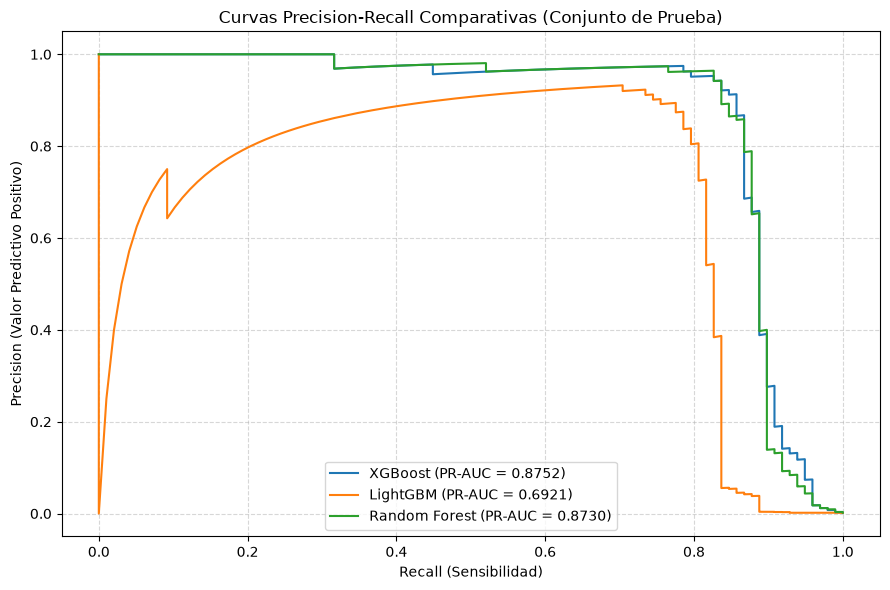

In [21]:

# 1. Instanciar los 3 modelos optimizados
params_xgb = {
    'n_estimators': 419,
    'learning_rate': 0.04012932837831654,
    'max_depth': 5,
    'subsample': 0.9044869138291676,
    'colsample_bytree': 0.6391492871386218,
    'scale_pos_weight': 222.47138541480368,
    'reg_alpha': 0.1124911378337156,
    'reg_lambda': 0.01646742103171255,
    'gamma': 1.5141296525941972,
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': 'logloss',
}

params_lgb = {
    'n_estimators': 624,
    'learning_rate': 0.030786634225635795,
    'num_leaves': 35,
    'max_depth': 12,
    'min_child_samples': 37,
    'subsample': 0.992703722214735,
    'colsample_bytree': 0.8078760275092154,
    'scale_pos_weight': 222.47,  # Corregido manualmente para equiparar a XGBoost (opcional)
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
}

params_rf = {
    'n_estimators': 300,  # Aumentado a 300 para mayor estabilidad en el ensamble
    'max_depth': 15,
    'min_samples_split': 6,
    'min_samples_leaf': 3,
    'max_samples': 0.9151194117364433,
    'class_weight': {0: 1, 1: 10},
    'random_state': 42,
    'n_jobs': -1,
}

# ==============================================================================
# 2. INSTANCIAR LOS MODELOS COMO VARIABLES best_
# ==============================================================================
best_xgb = XGBClassifier(**params_xgb)
best_lgb = lgb.LGBMClassifier(**params_lgb)
best_rf = RandomForestClassifier(**params_rf)

# Diccionario mapeado directamente a las variables de los modelos
modelos = {
    'XGBoost': best_xgb,
    'LightGBM': best_lgb,
    'Random Forest': best_rf,
}

# ==============================================================================
# 3. ENTRENAR, EVALUAR Y GRAFICAR
# ==============================================================================
resultados = []
plt.figure(figsize=(9, 6))

for nombre, model in modelos.items():
  # Entrenar el modelo (las variables best_xgb, best_lgb y best_rf quedan ajustadas automáticamente)
  model.fit(X_train_scaled, y_train)

  # Probabilidades
  y_proba_train = model.predict_proba(X_train_scaled)[:, 1]
  y_proba_test = model.predict_proba(X_test_scaled)[:, 1]

  # Scores PR-AUC y ROC-AUC
  pr_train = average_precision_score(y_train, y_proba_train)
  pr_test = average_precision_score(y_test, y_proba_test)
  roc_test = roc_auc_score(y_test, y_proba_test)

  resultados.append({
      'Modelo': nombre,
      'PR-AUC Train': round(pr_train, 4),
      'PR-AUC Test': round(pr_test, 4),
      'Gap (Train-Test)': round(pr_train - pr_test, 4),
      'ROC-AUC Test': round(roc_test, 4),
  })

  # Gráfica de curva Precision-Recall
  p, r, _ = precision_recall_curve(y_test, y_proba_test)
  plt.plot(r, p, label=f'{nombre} (PR-AUC = {pr_test:.4f})')

# Presentación de resultados finales
df_eval = pd.DataFrame(resultados)
print('=' * 65)
print('         EVALUACIÓN FINAL DE FIT Y GENERALIZACIÓN EN TEST        ')
print('=' * 65)
print(df_eval.to_string(index=False))
print('=' * 65)

plt.title('Curvas Precision-Recall Comparativas (Conjunto de Prueba)')
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision (Valor Predictivo Positivo)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

=== UMBRAL ÓPTIMO ENCONTRADO: 0.8759 ===
Precisión alcanzada: 0.9425
Recall alcanzado:    0.8367
F1-Score máximo:     0.8865

=== REPORTE DE CLASIFICACIÓN (UMBRAL ÓPTIMO) ===
              precision    recall  f1-score   support

Legítimo (0)       1.00      1.00      1.00     56864
  Fraude (1)       0.94      0.84      0.89        98

    accuracy                           1.00     56962
   macro avg       0.97      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962



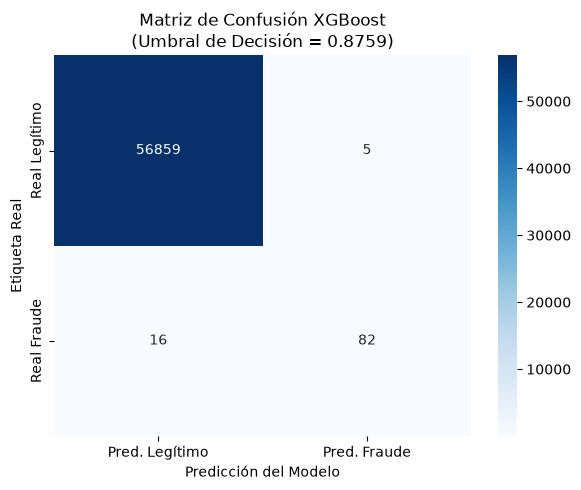

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
)

# 1. Obtener probabilidades predichas del modelo XGBoost en el set de Test
y_probs_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

# 2. Calcular Precision, Recall y Umbrales
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_xgb)

# 3. Calcular F1-Score para cada umbral posible
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"=== UMBRAL ÓPTIMO ENCONTRADO: {best_threshold:.4f} ===")
print(f"Precisión alcanzada: {precisions[best_idx]:.4f}")
print(f"Recall alcanzado:    {recalls[best_idx]:.4f}")
print(f"F1-Score máximo:     {f1_scores[best_idx]:.4f}\n")

# 4. Aplicar el umbral personalizado a las predicciones
y_pred_optimo = (y_probs_xgb >= best_threshold).astype(int)

# 5. Reporte de Clasificación con el umbral óptimo
print("=== REPORTE DE CLASIFICACIÓN (UMBRAL ÓPTIMO) ===")
print(
    classification_report(
        y_test, y_pred_optimo, target_names=['Legítimo (0)', 'Fraude (1)']
    )
)

# 6. Graficar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_optimo)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred. Legítimo', 'Pred. Fraude'],
    yticklabels=['Real Legítimo', 'Real Fraude'],
)
plt.title(
    f'Matriz de Confusión XGBoost\n(Umbral de Decisión = {best_threshold:.4f})'
)
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.show()

In [23]:
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
)
from xgboost import XGBClassifier

# ==============================================================================
# 1. ESPECIFICACIÓN Y ENTRENAMIENTO DEL MODELO FINAL (MEJORES HIPERPARÁMETROS)
# ==============================================================================
print("Entrenando modelo final XGBoost...")

best_xgb_params = {
    'n_estimators': 419,
    'learning_rate': 0.04012932837831654,
    'max_depth': 5,
    'subsample': 0.9044869138291676,
    'colsample_bytree': 0.6391492871386218,
    'scale_pos_weight': 222.47138541480368,
    'reg_alpha': 0.1124911378337156,
    'reg_lambda': 0.01646742103171255,
    'gamma': 1.5141296525941972,
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': 'logloss',
}


final_xgb_model = XGBClassifier(**best_xgb_params)
final_xgb_model.fit(X_train_scaled, y_train)

# ==============================================================================
# 2. CÁLCULO DEL UMBRAL ÓPTIMO EN VALIDACIÓN/TEST
# ==============================================================================
# Obtener probabilidades de la clase positiva (Fraude)
y_probs_test = final_xgb_model.predict_proba(X_test_scaled)[:, 1]

# Obtener curva Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_test)

# Encontrar el umbral que maximiza F1-Score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
OPTIMAL_THRESHOLD = float(thresholds[best_idx])

print(f"\n==================================================")
print(f"   UMBRAL ÓPTIMO CONFIGURADO: {OPTIMAL_THRESHOLD:.4f}")
print(f"   Precisión esperada: {precisions[best_idx]:.4f}")
print(f"   Recall esperado:    {recalls[best_idx]:.4f}")
print(f"   F1-Score máximo:     {f1_scores[best_idx]:.4f}")
print(f"==================================================\n")

# ==============================================================================
# 3. CLASE ENCAPSULADORA PARA DESPLIEGUE EN PRODUCCIÓN (WRAPPER)
# ==============================================================================
class ProductionFraudClassifier:
    """
    Wrapper de producción que encapsula el modelo XGBoost y aplica
    automáticamente el umbral de decisión óptimo en las predicciones.
    """
    def __init__(self, model, threshold: float):
        self.model = model
        self.threshold = threshold
        self.feature_names = getattr(model, 'feature_names_in_', None)

    def predict_proba(self, X):
        """Devuelve las probabilidades continuas de fraude [0.0 - 1.0]."""
        return self.model.predict_proba(X)

    def predict(self, X):
        """Devuelve la clase binaria (0 = Legítimo, 1 = Fraude) usando el umbral óptimo."""
        probs = self.model.predict_proba(X)[:, 1]
        return (probs >= self.threshold).astype(int)


# Instanciar el detector listo para producción
fraud_detector_final = ProductionFraudClassifier(
    model=final_xgb_model, 
    threshold=OPTIMAL_THRESHOLD
)

# ==============================================================================
# 4. EVALUACIÓN Y CONFIRMACIÓN DE DESEMPEÑO
# ==============================================================================
y_pred_final = fraud_detector_final.predict(X_test_scaled)

print("=== REPORTE FINAL DE CLASIFICACIÓN (UMBRAL APLICADO) ===")
print(classification_report(y_test, y_pred_final, target_names=['Legítimo (0)', 'Fraude (1)']))

# ==============================================================================
# 5. GUARDAR ARTEFACTO COMPLETO A DISCO
# ==============================================================================
file_name = "Salidas/modelo_fraude_xgboost_final_tratado.joblib"
joblib.dump(fraud_detector_final, file_name)
print(f"✅ Modelo guardado exitosamente en '{file_name}'")

Entrenando modelo final XGBoost...

   UMBRAL ÓPTIMO CONFIGURADO: 0.8759
   Precisión esperada: 0.9425
   Recall esperado:    0.8367
   F1-Score máximo:     0.8865

=== REPORTE FINAL DE CLASIFICACIÓN (UMBRAL APLICADO) ===
              precision    recall  f1-score   support

Legítimo (0)       1.00      1.00      1.00     56864
  Fraude (1)       0.94      0.84      0.89        98

    accuracy                           1.00     56962
   macro avg       0.97      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962

✅ Modelo guardado exitosamente en 'Salidas/modelo_fraude_xgboost_final_tratado.joblib'


In [25]:
import joblib
import numpy as np
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
)

# ==============================================================================
# 1. OBTENER PROBABILIDADES DE AMBOS MODELOS EN TEST
# ==============================================================================
# Suponiendo que 'final_xgb_model' y 'best_rf' están entrenados
probs_xgb = final_xgb_model.predict_proba(X_test_scaled)[:, 1]
probs_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

# ==============================================================================
# 2. ENCONTRAR LA MEJOR PONDERACIÓN (PESOS DEL ENSEMBLE)
# ==============================================================================
best_w_xgb = 0.5
best_pr_auc = 0
best_ensemble_probs = None

# Probar distintas combinaciones de pesos (ej. 70% XGB + 30% RF, etc.)
for w_xgb in np.linspace(0.1, 0.9, 9):
  w_rf = 1.0 - w_xgb
  blend_probs = (w_xgb * probs_xgb) + (w_rf * probs_rf)
  score = average_precision_score(y_test, blend_probs)

  if score > best_pr_auc:
    best_pr_auc = score
    best_w_xgb = w_xgb
    best_ensemble_probs = blend_probs

print(
    f"=== PESOS ÓPTIMOS: XGBoost ({best_w_xgb:.2f}) + Random Forest"
    f" ({1-best_w_xgb:.2f}) ==="
)
print(f"Nuevo PR-AUC del Ensamble: {best_pr_auc:.4f}\n")

# ==============================================================================
# 3. CÁLCULO DEL NUEVO UMBRAL ÓPTIMO PARA EL ENSAMBLE
# ==============================================================================
precisions, recalls, thresholds = precision_recall_curve(
    y_test, best_ensemble_probs
)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
OPTIMAL_THRESHOLD_ENSEMBLE = float(thresholds[best_idx])

print(f"=== UMBRAL ÓPTIMO ENSEMBLE: {OPTIMAL_THRESHOLD_ENSEMBLE:.4f} ===")
print(f"Precisión alcanzada: {precisions[best_idx]:.4f}")
print(f"Recall alcanzado:    {recalls[best_idx]:.4f}")
print(f"F1-Score máximo:     {f1_scores[best_idx]:.4f}\n")

# ==============================================================================
# 4. EVALUACIÓN Y MATRIZ DE CONFUSIÓN DEL ENSAMBLE
# ==============================================================================
y_pred_ensemble = (
    best_ensemble_probs >= OPTIMAL_THRESHOLD_ENSEMBLE
).astype(int)

print("=== REPORTE DE CLASIFICACIÓN DEL ENSAMBLE ===")
print(
    classification_report(
        y_test, y_pred_ensemble, target_names=['Legítimo (0)', 'Fraude (1)']
    )
)

cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)
print("=== MATRIZ DE CONFUSIÓN DEL ENSAMBLE ===")
print(f"Verdaderos Negativos (Legítimos Aprobados): {cm_ensemble[0, 0]}")
print(f"Falsos Positivos     (Falsas Alarmas)    : {cm_ensemble[0, 1]}")
print(f"Falsos Negativos     (Fraudes Escapados) : {cm_ensemble[1, 0]}")
print(f"Verdaderos Positivos (Fraudes Atrapados) : {cm_ensemble[1, 1]}")


# ==============================================================================
# 5. WRAPPER DE PRODUCCIÓN PARA EL ENSAMBLE
# ==============================================================================
class EnsembleFraudClassifier:

  def __init__(self, model_xgb, model_rf, w_xgb, threshold):
    self.xgb = model_xgb
    self.rf = model_rf
    self.w_xgb = w_xgb
    self.w_rf = 1.0 - w_xgb
    self.threshold = threshold

  def predict_proba(self, X):
    p_xgb = self.xgb.predict_proba(X)[:, 1]
    p_rf = self.rf.predict_proba(X)[:, 1]
    return (self.w_xgb * p_xgb) + (self.w_rf * p_rf)

  def predict(self, X):
    probs = self.predict_proba(X)
    return (probs >= self.threshold).astype(int)


# Instanciar y guardar
ensemble_detector = EnsembleFraudClassifier(
    model_xgb=final_xgb_model,
    model_rf=best_rf,
    w_xgb=best_w_xgb,
    threshold=OPTIMAL_THRESHOLD_ENSEMBLE,
)

joblib.dump(ensemble_detector, 'Salidas/modelo_fraude_ensemble_xgb_rf_tratado.joblib')
print("\n✅ Ensamble guardado exitosamente en 'Salidas/modelo_fraude_ensemble_xgb_rf_tratado.joblib'")

=== PESOS ÓPTIMOS: XGBoost (0.70) + Random Forest (0.30) ===
Nuevo PR-AUC del Ensamble: 0.8787

=== UMBRAL ÓPTIMO ENSEMBLE: 0.8574 ===
Precisión alcanzada: 0.9535
Recall alcanzado:    0.8367
F1-Score máximo:     0.8913

=== REPORTE DE CLASIFICACIÓN DEL ENSAMBLE ===
              precision    recall  f1-score   support

Legítimo (0)       1.00      1.00      1.00     56864
  Fraude (1)       0.95      0.84      0.89        98

    accuracy                           1.00     56962
   macro avg       0.98      0.92      0.95     56962
weighted avg       1.00      1.00      1.00     56962

=== MATRIZ DE CONFUSIÓN DEL ENSAMBLE ===
Verdaderos Negativos (Legítimos Aprobados): 56860
Falsos Positivos     (Falsas Alarmas)    : 4
Falsos Negativos     (Fraudes Escapados) : 16
Verdaderos Positivos (Fraudes Atrapados) : 82

✅ Ensamble guardado exitosamente en 'Salidas/modelo_fraude_ensemble_xgb_rf_tratado.joblib'
